In [ ]:
# System tools
import os
import sys

# Data IO tools
from BDT_model.HLTIO import preprocess
import pandas as pd
import pickle

# ML tools
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
import matplotlib.pyplot as plt
import itertools
from sklearn.metrics import roc_auc_score, accuracy_score, confusion_matrix, roc_curve, auc
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Progress bar tools
from tqdm.notebook import tqdm  # Notebook version for better display in Jupyter
# from tqdm import tqdm  # Notebook version for better display in Jupyter

# QNN tools
import pennylane as qml

In [1]:
################
# Data IO part #
################

# Assuming your project structure as above, add the parent directory to sys.path
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if project_root not in sys.path:
    sys.path.append(project_root)

# Path to the original pickle file
pkl_path = "./DYToLL_PU200_Spring23_NThltIter2FromL1/DYToLL_PU200_Spring23_NThltIter2FromL1_Barrel.pkl"

# Load the pickle file
with open(pkl_path, "rb") as file:
    data = pickle.load(file)

# Assume the first element of the tuple is the original DataFrame
df = data[0]

# pT cut
df = df[ df['gen_pt'] < 1e9 ]
df = df[ df['gen_pt'] > 0 ]
# Apply setClassLabel to compute the class labels
df = preprocess.setClassLabel(df)
# Compute the distance features (expd2hitl1tk1,..,expd2hitl1tk4) 
# We use addAbsDist=False as in the readSeedTree flow to drop the d2hitl1tk variables.
df = preprocess.addDistHitL1Tk(df, addAbsDist=False)
df = df[((df['tsos_eta'] < 1.2) & (df['tsos_eta'] > -1.2))].copy()

# Define the list of required columns:
required_columns = [
    "expd2hitl1tk1",
    "expd2hitl1tk2",
    "expd2hitl1tk3",
    "dR_L1TkMuSeedP",
    "dPhi_L1TkMuSeedP",
    "tsos_qbp",
    "tsos_dydz",
    "tsos_dxdz",
    "tsos_err0",
    "tsos_err2",
    "tsos_err5",
    "y_label"  # class label from setClassLabel
]

# Check whether all required columns are present; if not, issue a warning.
missing = [col for col in required_columns if col not in df.columns]
if missing:
    print("Warning: The following required columns are missing:", missing)

# Create a new DataFrame with only the required columns.
df_final = df[required_columns].copy()
df_final = df_final.fillna(-1.) # fillna(-1.) for QNN

# Display the first few rows of the final DataFrame
print(df_final.head())

# Optionally, save the resulting DataFrame to an Excel file.
# df_final.to_excel("processed_data.xlsx", index=False)

# Check if the NaNs are filled with -1.
print(df_final[df_final["y_label"] == 0])

   expd2hitl1tk1  expd2hitl1tk2  expd2hitl1tk3  dR_L1TkMuSeedP  \
0       0.990987       0.713180       0.987402        0.004175   
1       0.689316       0.764362       0.674484        0.005500   
2       0.548451       0.480737       0.999237        0.027850   
3       0.767553       0.994757       0.998245        0.008985   
4       0.741779       0.999612       0.997960        0.001913   

   dPhi_L1TkMuSeedP  tsos_qbp  tsos_dydz  tsos_dxdz  tsos_err0     tsos_err2  \
0         -0.003510 -0.023912  -0.335638  -0.038410   0.000043  6.029049e-08   
1          0.004065  0.025677  -0.411500   0.036356   0.000068  6.829735e-08   
2         -0.027783 -0.109400   1.075664   0.080918   0.000016  1.170655e-07   
3         -0.008914 -0.055924   0.417587   0.080094   0.000023  6.257859e-08   
4          0.001653  0.009154   0.334038  -0.009316   0.000005  2.613838e-08   

      tsos_err5  y_label  
0  1.060757e-07      1.0  
1  7.030542e-08      1.0  
2  2.279720e-07      1.0  
3  7.708970e-0

In [ ]:
################
# Data slicing #
################

# Specify which GPU to use (e.g., use GPU 1 instead of GPU 0)
gpu_id = 0  # Change this to the ID of the GPU you want to use
torch.cuda.set_device(gpu_id)
device = torch.device(f"cuda:{gpu_id}" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# # Slicing the data
# # Randomly select 300 indices from the DataFrame
# random_indices = np.random.choice(df_final.index, size=300, replace=False)
# df_sampled = df_final.loc[random_indices]

# # Check if the class label is balanced
# print(df_sampled["y_label"].value_counts())

# X = torch.tensor(df_sampled.drop(columns=["y_label"]).values, dtype=torch.float32)
# y = torch.tensor(df_sampled["y_label"].values, dtype=torch.float32).unsqueeze(1)

# Instead of converting directly to torch tensors, first convert the DataFrame to numpy arrays.
X_np = df_final.drop(columns=["y_label"]).values.astype(np.float32)
y_np = df_final["y_label"].values.astype(np.float32).reshape(-1, 1)

# Split the data into training and test sets (80% train, 20% test) with stratification.
x_train_np, x_test_np, y_train_np, y_test_np = train_test_split(
    X_np, y_np, test_size=0.2, random_state=42, stratify=y_np
)

# Compute scaling parameters (mean and scale) using training data.
scaler = StandardScaler()
scaler.fit(x_train_np)
stdTransPar = [scaler.mean_, scaler.scale_]

# --- NEW SECTION: Write out scaling parameters for future inference ---
scalefiles_dir = "scalefiles"
if not os.path.exists(scalefiles_dir):
    os.makedirs(scalefiles_dir)
scale_filepath = os.path.join(scalefiles_dir, "barrel_qnn_scale.txt")
with open(scale_filepath, "w") as f_scale:
    f_scale.write("%s\n" % str(scaler.mean_.tolist()))
    f_scale.write("%s\n" % str(scaler.scale_.tolist()))
# --- END NEW SECTION ---

# Standardize both training and test data using the fixed transformation,
# exactly as in your BDT script.
x_train_np, x_test_np = preprocess.stdTransformFixed(x_train_np, x_test_np, stdTransPar)

# Now convert the standardized numpy arrays to torch tensors and move them to the GPU device.
x_train = torch.tensor(x_train_np, dtype=torch.float32).to(device)
x_test  = torch.tensor(x_test_np, dtype=torch.float32).to(device)
y_train = torch.tensor(y_train_np, dtype=torch.float32).to(device)
y_test  = torch.tensor(y_test_np, dtype=torch.float32).to(device)

# Print class distributions on train/test splits to verify stratification.
print("Training set class distribution:")
print(pd.Series(y_train.cpu().numpy().flatten()).value_counts())
print("Test set class distribution:")
print(pd.Series(y_test.cpu().numpy().flatten()).value_counts())


Using device: cuda:0
Training set class distribution:
0.0    40893
1.0    32798
Name: count, dtype: int64
Test set class distribution:
0.0    10224
1.0     8199
Name: count, dtype: int64


Epochs:   0%|          | 0/5 [00:00<?, ?it/s]

Epoch 1 Batches:   0%|          | 0/737 [00:00<?, ?it/s]

Epoch 1/5
Train Loss: 0.2565, Test Loss: 0.1562
ROC AUC: 0.9920, Accuracy: 0.9702
Confusion Matrix:
[[9935  289]
 [ 260 7939]]


Epoch 2 Batches:   0%|          | 0/737 [00:00<?, ?it/s]

Epoch 2/5
Train Loss: 0.1487, Test Loss: 0.1498
ROC AUC: 0.9923, Accuracy: 0.9725
Confusion Matrix:
[[9918  306]
 [ 201 7998]]


...

Epoch 3/5
Train Loss: 0.1472, Test Loss: 0.1498
ROC AUC: 0.9920, Accuracy: 0.9719
Confusion Matrix:
[[9901  323]
 [ 195 8004]]


Epoch 4 Batches:   0%|          | 0/737 [00:00<?, ?it/s]

Epoch 4/5
Train Loss: 0.1467, Test Loss: 0.1490
ROC AUC: 0.9921, Accuracy: 0.9710
Confusion Matrix:
[[9921  303]
 [ 231 7968]]


Epoch 5 Batches:   0%|          | 0/737 [00:00<?, ?it/s]

Epoch 5/5
Train Loss: 0.1463, Test Loss: 0.1490
ROC AUC: 0.9922, Accuracy: 0.9711
Confusion Matrix:
[[9925  299]
 [ 234 7965]]


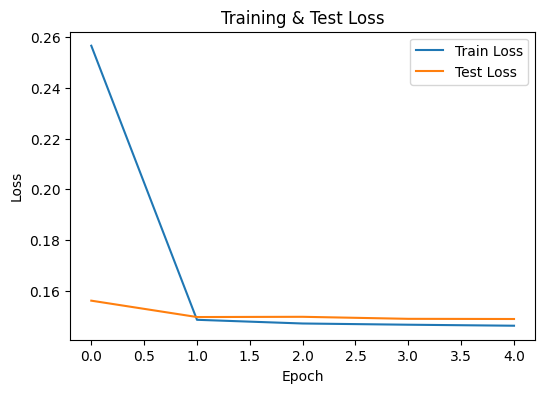

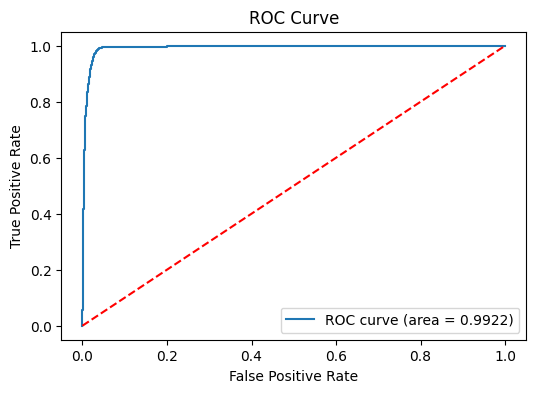

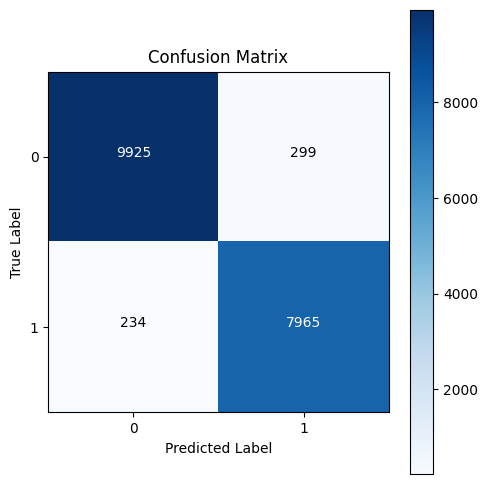

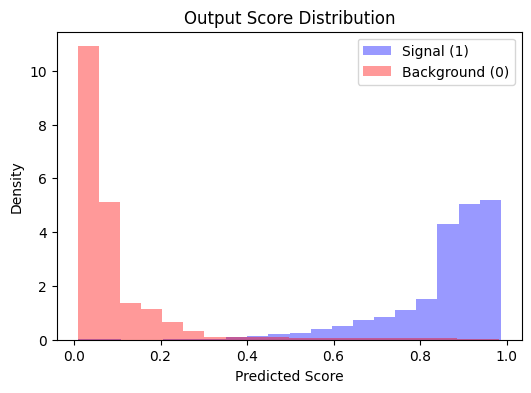

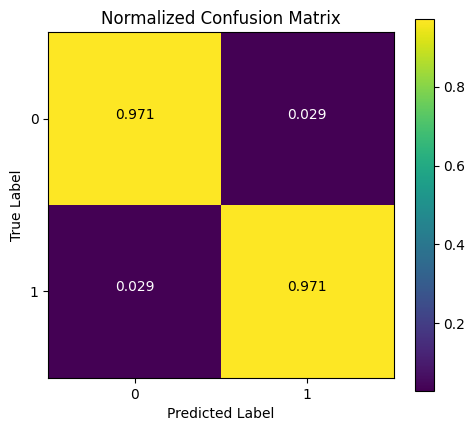

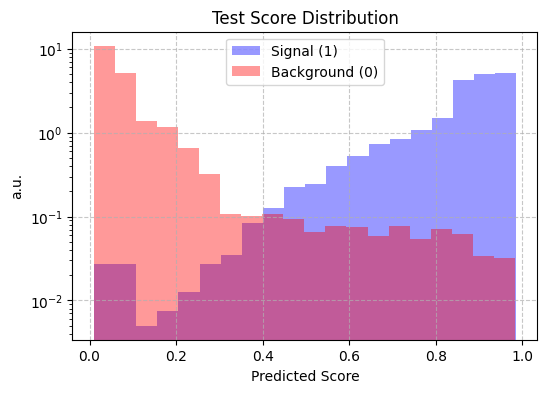

In [5]:
# -----------------------------------------------------------------------------
# QNN Model Definition for Binary Classification
# -----------------------------------------------------------------------------
# Set number of qubits to 11 (to match 11 input features)
n_qubits = 11  
q_depth = 5   # This will be used only for StronglyEntanglingLayers
qaoa_depth = 1 # New parameter for QAOAEmbedding
output_dim = 1  # Only one measurement for binary classification

# Using a potentially GPU-accelerated device (if you have installed pennylane-lightning with GPU support)
# dev = qml.device("lightning.qubit", wires=n_qubits)
dev = qml.device("default.qubit", wires=n_qubits)


@qml.qnode(dev, interface="torch")
def qnode(inputs, weights1, weights2):
    # QAOA embedding layer: embed the input data (just 1 layer now)
    qml.templates.QAOAEmbedding(inputs, weights=weights1, wires=range(n_qubits))
    # Keep 5 strongly entangling layers for quantum processing
    qml.templates.StronglyEntanglingLayers(weights2, wires=range(n_qubits))
    # Return one expectation value from qubit 0 for classification 
    return [qml.expval(qml.PauliZ(0))]

# Define the weight shapes taking into account the new configuration
weight_shapes = {
    "weights1": (qaoa_depth, 2 * n_qubits),  # Just 1 QAOA layer
    "weights2": (q_depth, n_qubits, 3)       # Keep 5 StronglyEntanglingLayers
}

# Create a TorchLayer that wraps the quantum node
qlayer = qml.qnn.TorchLayer(qnode, weight_shapes)

class PureQNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.qlayer = qlayer  

    def forward(self, x):
        # The raw output of the QNN is in [-1,1]. Convert it to [0,1] as a probability.
        return (self.qlayer(x) + 1) / 2

# # Instantiate the binary classification model
# model = PureQNN()
# When instantiating your model, move it to the GPU
model = PureQNN().to(device)

# Use AdamW optimizer; adjust the learning rate as needed.
optimizer = optim.AdamW(model.parameters(), lr=0.01)
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=5)
criterion = nn.BCELoss()  # Binary cross-entropy loss for classification

# Early stopping parameters
best_test_loss = float('inf')
patience_counter = 0
early_stopping_patience = 10

epochs = 5
batch_size = 100
train_losses = []
test_losses = []

# Outer epoch loop (position=0)
for epoch in tqdm(range(epochs), desc="Epochs", position=0, leave=True):
    model.train()
    running_loss = 0.0
    perm = torch.randperm(len(x_train))
    batch_steps = list(range(0, len(x_train), batch_size))
    
    # Inner batch loop (position=1)
    for i in tqdm(batch_steps, desc=f"Epoch {epoch+1} Batches", leave=True, position=1):
        indices = perm[i : i + batch_size]
        # x_batch, y_batch = x_train[indices], y_train[indices]
        x_batch, y_batch = x_train[indices].to(device), y_train[indices].to(device)
        
        optimizer.zero_grad()
        y_pred = model(x_batch)
        loss = criterion(y_pred, y_batch)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
    
    avg_train_loss = running_loss / (len(x_train) / batch_size)
    train_losses.append(avg_train_loss)
    
    # Evaluate on test set
    model.eval()
    with torch.no_grad():
        y_test_pred = model(x_test)
        test_loss = criterion(y_test_pred, y_test).item()
        test_losses.append(test_loss)
    
    scheduler.step(test_loss)
    
    # Compute metrics for logging
    y_test_prob = y_test_pred.cpu().numpy().flatten()
    y_test_np = y_test.cpu().numpy().flatten()
    y_pred_labels = (y_test_prob >= 0.5).astype(int)
    roc_auc = roc_auc_score(y_test_np, y_test_prob)
    accuracy = accuracy_score(y_test_np, y_pred_labels)
    
    # Log metrics without interfering with the progress bars
    tqdm.write(f"Epoch {epoch+1}/{epochs}")
    tqdm.write(f"Train Loss: {avg_train_loss:.4f}, Test Loss: {test_loss:.4f}")
    tqdm.write(f"ROC AUC: {roc_auc:.4f}, Accuracy: {accuracy:.4f}")
    tqdm.write("Confusion Matrix:")
    tqdm.write(f"{confusion_matrix(y_test_np, y_pred_labels)}")
    
    # Early stopping check
    if test_loss < best_test_loss:
        best_test_loss = test_loss
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= early_stopping_patience:
            tqdm.write(f"Early stopping triggered at epoch {epoch+1}")
            break

# -----------------------------------------------------------------------------
# Save the model (do not save model when running from Jupyter notebook)
# -----------------------------------------------------------------------------

# Option 1: Save the entire model (architecture + weights) -> does not work for QNN
# torch.save(model, 'qnn_seed_classifier_full.pt')

# Option 2: Save only the model state dictionary (recommended)
# torch.save(model.state_dict(), './barrel_result/qnn_seed_classifier_weights_barrel.pt')

# You can also save additional training information if needed
# training_info = {
#     'train_losses': train_losses,
#     'test_losses': test_losses,
#     'best_test_loss': best_test_loss,
#     'epochs_completed': epoch + 1,
#     'hyperparameters': {
#         'n_qubits': n_qubits,
#         'q_depth': q_depth,
#         'qaoa_depth': qaoa_depth,
#         'batch_size': batch_size,
#         'learning_rate': optimizer.param_groups[0]['lr']
#     }
# }
# torch.save(training_info, './barrel_result/qnn_training_info_barrel.pt')

# -----------------------------------------------------------------------------
# Plot Training and Test Loss
# -----------------------------------------------------------------------------

plt.figure(figsize=(6, 4))
plt.plot(train_losses, label="Train Loss")
plt.plot(test_losses, label="Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Training & Test Loss")
# plt.savefig("./barrel_result/Training_Test_Loss_barrel.png", dpi=300, bbox_inches='tight')
plt.show()
# -----------------------------------------------------------------------------
# Final Evaluation on Test Set: ROC Curve, Confusion Matrix, and Score Distribution
# -----------------------------------------------------------------------------

with torch.no_grad():
    y_test_pred = model(x_test)
    y_test_prob = y_test_pred.cpu().numpy().flatten()
    y_test_np = y_test.cpu().numpy().flatten()
    y_pred_labels = (y_test_prob >= 0.5).astype(int)
    final_conf_matrix = confusion_matrix(y_test_np, y_pred_labels)

# ROC Curve Plot
fpr, tpr, thresholds = roc_curve(y_test_np, y_test_prob)
roc_auc_val = auc(fpr, tpr)
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f"ROC curve (area = {roc_auc_val:.4f})")
plt.plot([0, 1], [0, 1], 'r--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
# plt.savefig("./barrel_result/ROC_Curve_barrel.png", dpi=300, bbox_inches='tight')
plt.show()

# Confusion Matrix Plot
plt.figure(figsize=(5, 5))
plt.imshow(final_conf_matrix, interpolation='nearest', cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.colorbar()
tick_marks = np.arange(2)
plt.xticks(tick_marks, ['0', '1'])
plt.yticks(tick_marks, ['0', '1'])
thresh = final_conf_matrix.max() / 2.
for i, j in itertools.product(range(final_conf_matrix.shape[0]), range(final_conf_matrix.shape[1])):
    plt.text(j, i, format(final_conf_matrix[i, j], 'd'),
             horizontalalignment="center",
             color="white" if final_conf_matrix[i, j] > thresh else "black")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
# plt.savefig("./barrel_result/Confusion_Matrix_barrel.png", dpi=300, bbox_inches='tight')
plt.show()

# Output Score Distribution Plot
mask_signal = (y_test_np == 1)
mask_background = (y_test_np == 0)
plt.figure(figsize=(6, 4))
plt.hist(y_test_prob[mask_signal], bins=20, alpha=0.4, label="Signal (1)", color="blue", density=True)
plt.hist(y_test_prob[mask_background], bins=20, alpha=0.4, label="Background (0)", color="red", density=True)
plt.xlabel("Predicted Score")
plt.ylabel("Density")
plt.title("Output Score Distribution")
plt.legend()
# plt.savefig("./barrel_result/Output_Score_Distribution_barrel.png", dpi=300, bbox_inches='tight')
plt.show()

# -----------------------------------------------------------------------------
# Plot normalized confusion matrix
# -----------------------------------------------------------------------------

# Assume y_test_np (true labels) and y_pred_labels (predicted labels) are defined
cm = confusion_matrix(y_test_np, y_pred_labels)
# Normalize by row (i.e. true labels are normalized by the sum of each row)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(5, 5))
plt.imshow(cm_normalized, interpolation='nearest', cmap='viridis')
plt.title("Normalized Confusion Matrix")
# Shrink the colorbar to better match the plot size
plt.colorbar(shrink=0.8)

# Create tick marks for 0 and 1 classes
tick_marks = np.arange(2)
plt.xticks(tick_marks, ['0', '1'])
plt.yticks(tick_marks, ['0', '1'])

# Use a threshold to set text color contrast
thresh = cm_normalized.max() / 2.
for i, j in itertools.product(range(cm_normalized.shape[0]), range(cm_normalized.shape[1])):
    plt.text(j, i, f"{cm_normalized[i, j]:.3f}",
             horizontalalignment="center",
             color="black" if cm_normalized[i, j] > thresh else "white")

plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
# plt.savefig("./barrel_result/Normalized_Confusion_Matrix_barrel.png", dpi=300, bbox_inches='tight')
plt.show()

# -----------------------------------------------------------------------------
# Plot normalized test score distribution
# -----------------------------------------------------------------------------

# Assume y_test_prob is defined, and mask_signal/mask_background are set as:
mask_signal = (y_test_np == 1)
mask_background = (y_test_np == 0)

plt.figure(figsize=(6, 4))
plt.hist(y_test_prob[mask_signal], bins=20, alpha=0.4, label="Signal (1)", color="blue", density=True)
plt.hist(y_test_prob[mask_background], bins=20, alpha=0.4, label="Background (0)", color="red", density=True)
plt.xlabel("Predicted Score")
plt.ylabel("a.u.")
plt.title("Test Score Distribution")
plt.grid(True, ls="--", alpha=0.7)

# Set the y-axis to log-scale
plt.yscale("log")
plt.legend()
# plt.savefig("./barrel_result/Test_Score_Distribution_barrel.png", dpi=300, bbox_inches='tight')
plt.show()

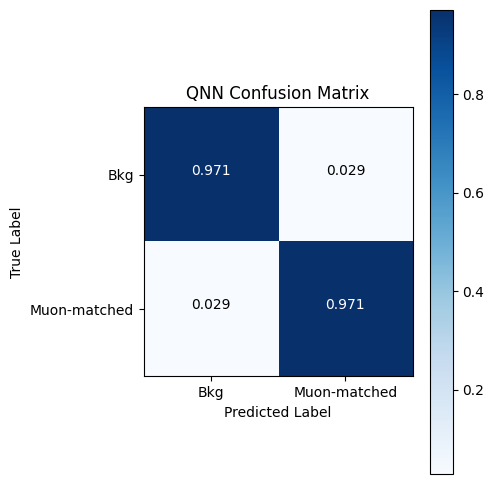

In [6]:
# Assume y_test_np (true labels) and y_pred_labels (predicted labels) are defined
cm = confusion_matrix(y_test_np, y_pred_labels)
# Normalize by row (i.e. true labels)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(5, 5))
plt.imshow(cm_normalized, interpolation='nearest', cmap=plt.cm.Blues)
plt.title("QNN Confusion Matrix")
plt.colorbar()

# Create tick marks for 0 and 1 classes
tick_marks = np.arange(2)
plt.xticks(tick_marks, ['Bkg', 'Muon-matched'])
plt.yticks(tick_marks, ['Bkg', 'Muon-matched'])

# Use a threshold to choose text color
thresh = cm_normalized.max() / 2.
for i, j in itertools.product(range(cm_normalized.shape[0]), range(cm_normalized.shape[1])):
    plt.text(j, i, f"{cm_normalized[i, j]:.3f}",
             horizontalalignment="center",
             color="white" if cm_normalized[i, j] > thresh else "black")

plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
# plt.savefig("Normalized_Confusion_Matrix.png", dpi=300, bbox_inches='tight')
plt.show()


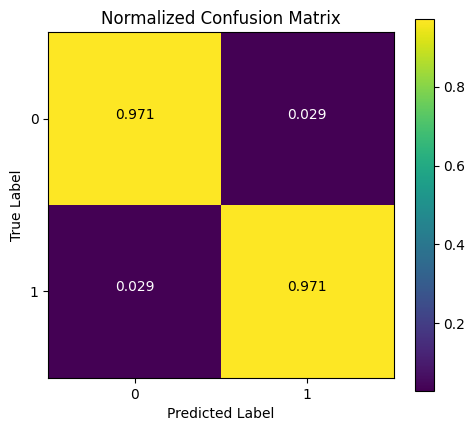

In [7]:
# Assume y_test_np (true labels) and y_pred_labels (predicted labels) are defined
cm = confusion_matrix(y_test_np, y_pred_labels)
# Normalize by row (i.e. true labels are normalized by the sum of each row)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(5, 5))
plt.imshow(cm_normalized, interpolation='nearest', cmap='viridis')
plt.title("Normalized Confusion Matrix")
# Shrink the colorbar to better match the plot size
plt.colorbar(shrink=0.8)

# Create tick marks for 0 and 1 classes
tick_marks = np.arange(2)
plt.xticks(tick_marks, ['0', '1'])
plt.yticks(tick_marks, ['0', '1'])

# Use a threshold to set text color contrast
thresh = cm_normalized.max() / 2.
for i, j in itertools.product(range(cm_normalized.shape[0]), range(cm_normalized.shape[1])):
    plt.text(j, i, f"{cm_normalized[i, j]:.3f}",
             horizontalalignment="center",
             color="black" if cm_normalized[i, j] > thresh else "white")

plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
# plt.savefig("Normalized_Confusion_Matrix.png", dpi=300, bbox_inches='tight')
plt.show()


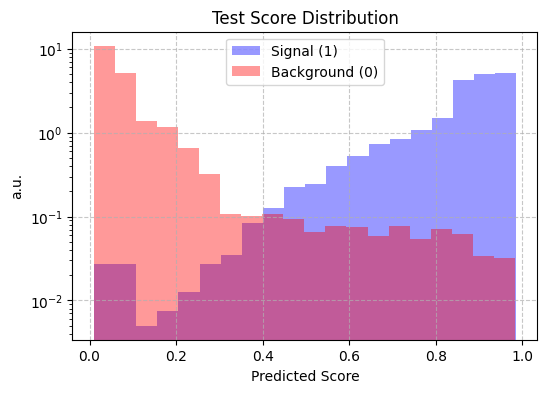

In [8]:
# Assume y_test_prob is defined, and mask_signal/mask_background are set as:
mask_signal = (y_test_np == 1)
mask_background = (y_test_np == 0)

plt.figure(figsize=(6, 4))
plt.hist(y_test_prob[mask_signal], bins=20, alpha=0.4, label="Signal (1)", color="blue", density=True)
plt.hist(y_test_prob[mask_background], bins=20, alpha=0.4, label="Background (0)", color="red", density=True)
plt.xlabel("Predicted Score")
plt.ylabel("a.u.")
plt.title("Test Score Distribution")
plt.grid(True, ls="--", alpha=0.7)

# Set the y-axis to log-scale
plt.yscale("log")
plt.legend()
# plt.savefig("Test_Score_Distribution.png", dpi=300, bbox_inches='tight')
plt.show()

Basic Circuit Diagram (Text)
 0: ─╭QAOAEmbedding─╭StronglyEntanglingLayers(M0)─┤  <Z>
 1: ─├QAOAEmbedding─├StronglyEntanglingLayers(M0)─┤     
 2: ─├QAOAEmbedding─├StronglyEntanglingLayers(M0)─┤     
 3: ─├QAOAEmbedding─├StronglyEntanglingLayers(M0)─┤     
 4: ─├QAOAEmbedding─├StronglyEntanglingLayers(M0)─┤     
 5: ─├QAOAEmbedding─├StronglyEntanglingLayers(M0)─┤     
 6: ─├QAOAEmbedding─├StronglyEntanglingLayers(M0)─┤     
 7: ─├QAOAEmbedding─├StronglyEntanglingLayers(M0)─┤     
 8: ─├QAOAEmbedding─├StronglyEntanglingLayers(M0)─┤     
 9: ─├QAOAEmbedding─├StronglyEntanglingLayers(M0)─┤     
10: ─╰QAOAEmbedding─╰StronglyEntanglingLayers(M0)─┤     

M0 = 
[[[0.36747818 0.90374764 0.81301598]
  [0.69380602 0.42008904 0.24587406]
  [0.86840351 0.57730988 0.03242799]
  [0.23869532 0.0500758  0.22639   ]
  [0.43504255 0.57932161 0.33880336]
  [0.28067543 0.2432196  0.16381827]
  [0.14536579 0.93837399 0.60652508]
  [0.24441659 0.67012566 0.01197484]
  [0.04191312 0.22831297 0.75833734]
  [0

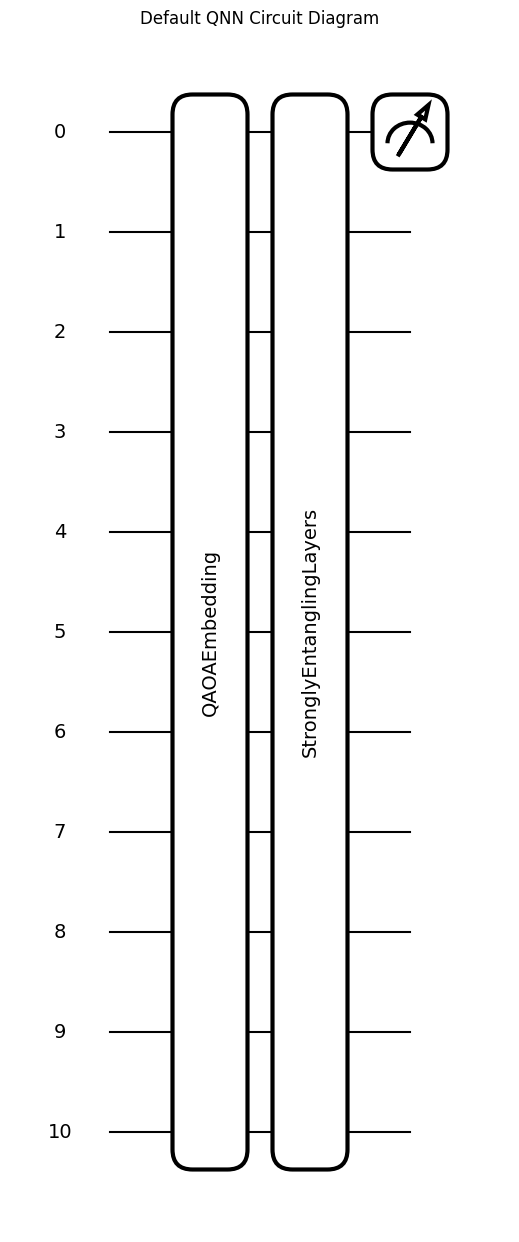

Expanded Circuit Diagram (Pennylane)
 0: ──RX(0.79)─╭MultiRZ(0.75)────────────────────────────────────────────────────────────
 1: ──RX(0.76)─╰MultiRZ(0.75)─╭MultiRZ(0.74)─────────────────────────────────────────────
 2: ──RX(0.67)────────────────╰MultiRZ(0.74)─╭MultiRZ(0.72)──────────────────────────────
 3: ──RX(0.45)───────────────────────────────╰MultiRZ(0.72)─╭MultiRZ(0.72)───────────────
 4: ──RX(0.30)──────────────────────────────────────────────╰MultiRZ(0.72)─╭MultiRZ(0.61)
 5: ──RX(0.18)─────────────────────────────────────────────────────────────╰MultiRZ(0.61)
 6: ──RX(0.46)───────────────────────────────────────────────────────────────────────────
 7: ──RX(0.82)───────────────────────────────────────────────────────────────────────────
 8: ──RX(0.38)───────────────────────────────────────────────────────────────────────────
 9: ──RX(0.08)───────────────────────────────────────────────────────────────────────────
10: ──RX(0.05)─────────────────────────────────────────────────

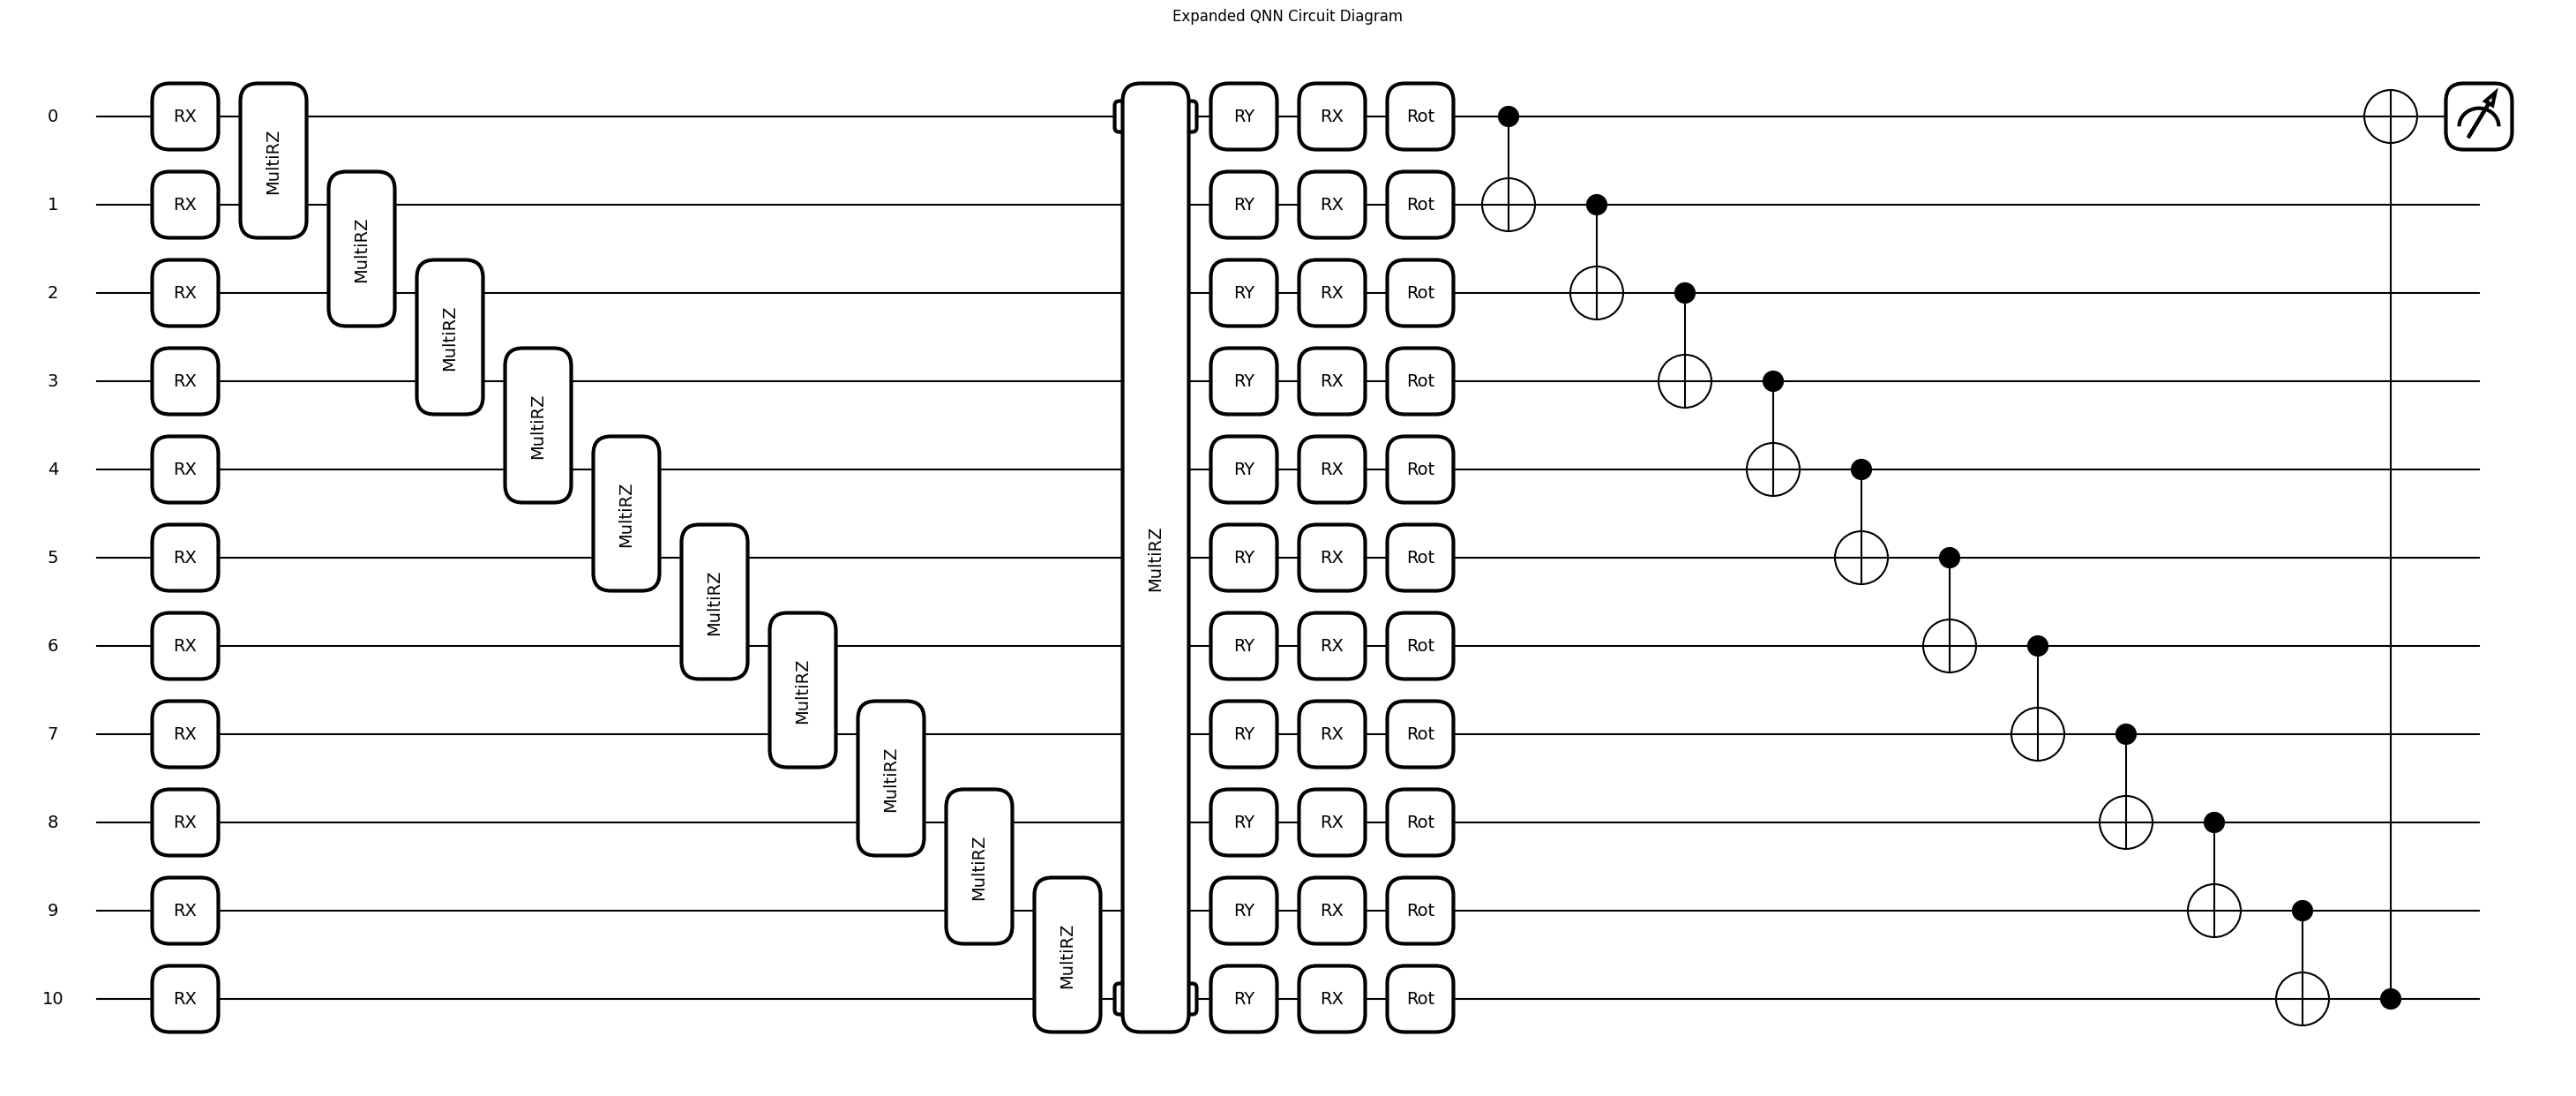

In [9]:
# Draw simplified (q_depth = 1) QNN diagram

# Set number of qubits to 11 (to match 11 input features)
n_qubits = 11  
q_depth = 1   
output_dim = 1  # Only one measurement for binary classification
dev = qml.device("default.qubit", wires=n_qubits)

@qml.qnode(dev, interface="torch")
def qnode(inputs, weights1, weights2):
    # QAOA embedding layer: embed the input data
    qml.templates.QAOAEmbedding(inputs, weights=weights1, wires=range(n_qubits))
    # Two strongly entangling layers for quantum processing
    qml.templates.StronglyEntanglingLayers(weights2, wires=range(n_qubits))
    # Return one expectation value from qubit 0 for classification 
    return [qml.expval(qml.PauliZ(0))]

ex_inputs   = np.random.random(n_qubits)
ex_weights1 = np.random.random((q_depth, 2 * n_qubits))
ex_weights2 = np.random.random((q_depth, n_qubits, 3))

# Basic Circuit Diagram (Text)
print("Basic Circuit Diagram (Text)")
default_diagram = qml.draw(qnode)(ex_inputs, ex_weights1, ex_weights2)
print(default_diagram)

fig_default = qml.draw_mpl(qnode)(ex_inputs, ex_weights1, ex_weights2)
plt.title("Default QNN Circuit Diagram")
plt.show()

# Expanded Circuit Diagram (Pennylane)
expanded_qnode = qml.transforms.decompose(qnode)

print("Expanded Circuit Diagram (Pennylane)")
expanded_diagram = qml.draw(expanded_qnode)(ex_inputs, ex_weights1, ex_weights2)
print(expanded_diagram)

fig_expanded = qml.draw_mpl(expanded_qnode)(ex_inputs, ex_weights1, ex_weights2)
plt.title("Expanded QNN Circuit Diagram")
plt.show()

Basic Circuit Diagram (Text)
 0: ─╭QAOAEmbedding─╭StronglyEntanglingLayers(M0)─┤  <Z>
 1: ─├QAOAEmbedding─├StronglyEntanglingLayers(M0)─┤     
 2: ─├QAOAEmbedding─├StronglyEntanglingLayers(M0)─┤     
 3: ─├QAOAEmbedding─├StronglyEntanglingLayers(M0)─┤     
 4: ─├QAOAEmbedding─├StronglyEntanglingLayers(M0)─┤     
 5: ─├QAOAEmbedding─├StronglyEntanglingLayers(M0)─┤     
 6: ─├QAOAEmbedding─├StronglyEntanglingLayers(M0)─┤     
 7: ─├QAOAEmbedding─├StronglyEntanglingLayers(M0)─┤     
 8: ─├QAOAEmbedding─├StronglyEntanglingLayers(M0)─┤     
 9: ─├QAOAEmbedding─├StronglyEntanglingLayers(M0)─┤     
10: ─╰QAOAEmbedding─╰StronglyEntanglingLayers(M0)─┤     

M0 = 
[[[6.90668155e-01 8.00147623e-01 9.08310375e-01]
  [4.36874489e-01 1.41501187e-01 3.99085003e-01]
  [6.20366184e-01 7.17191061e-01 4.80135940e-01]
  [9.44965511e-01 8.26727297e-01 9.99291783e-01]
  [4.50554331e-01 9.53733166e-01 5.59872365e-01]
  [1.02678322e-01 4.66494477e-01 9.57818584e-01]
  [3.13816062e-02 1.93432069e-01 7.44919370

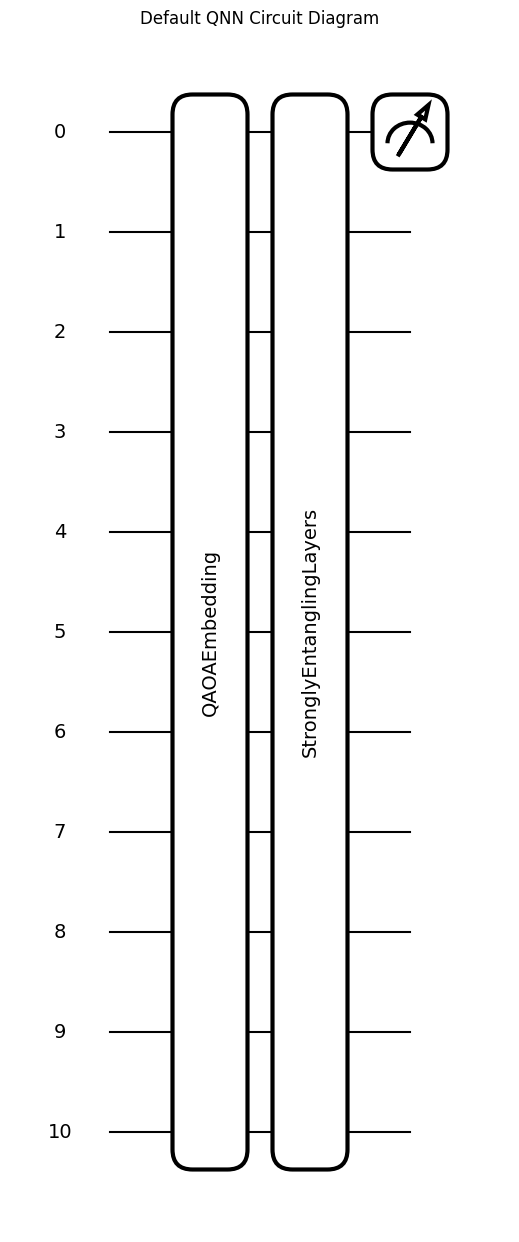

Expanded Circuit Diagram (Pennylane)
 0: ──RX(0.64)─╭MultiRZ(0.17)────────────────────────────────────────────────────────────
 1: ──RX(0.98)─╰MultiRZ(0.17)─╭MultiRZ(0.45)─────────────────────────────────────────────
 2: ──RX(0.40)────────────────╰MultiRZ(0.45)─╭MultiRZ(0.57)──────────────────────────────
 3: ──RX(0.76)───────────────────────────────╰MultiRZ(0.57)─╭MultiRZ(0.92)───────────────
 4: ──RX(0.68)──────────────────────────────────────────────╰MultiRZ(0.92)─╭MultiRZ(0.54)
 5: ──RX(0.09)─────────────────────────────────────────────────────────────╰MultiRZ(0.54)
 6: ──RX(0.65)───────────────────────────────────────────────────────────────────────────
 7: ──RX(0.96)───────────────────────────────────────────────────────────────────────────
 8: ──RX(0.87)───────────────────────────────────────────────────────────────────────────
 9: ──RX(0.97)───────────────────────────────────────────────────────────────────────────
10: ──RX(0.39)─────────────────────────────────────────────────

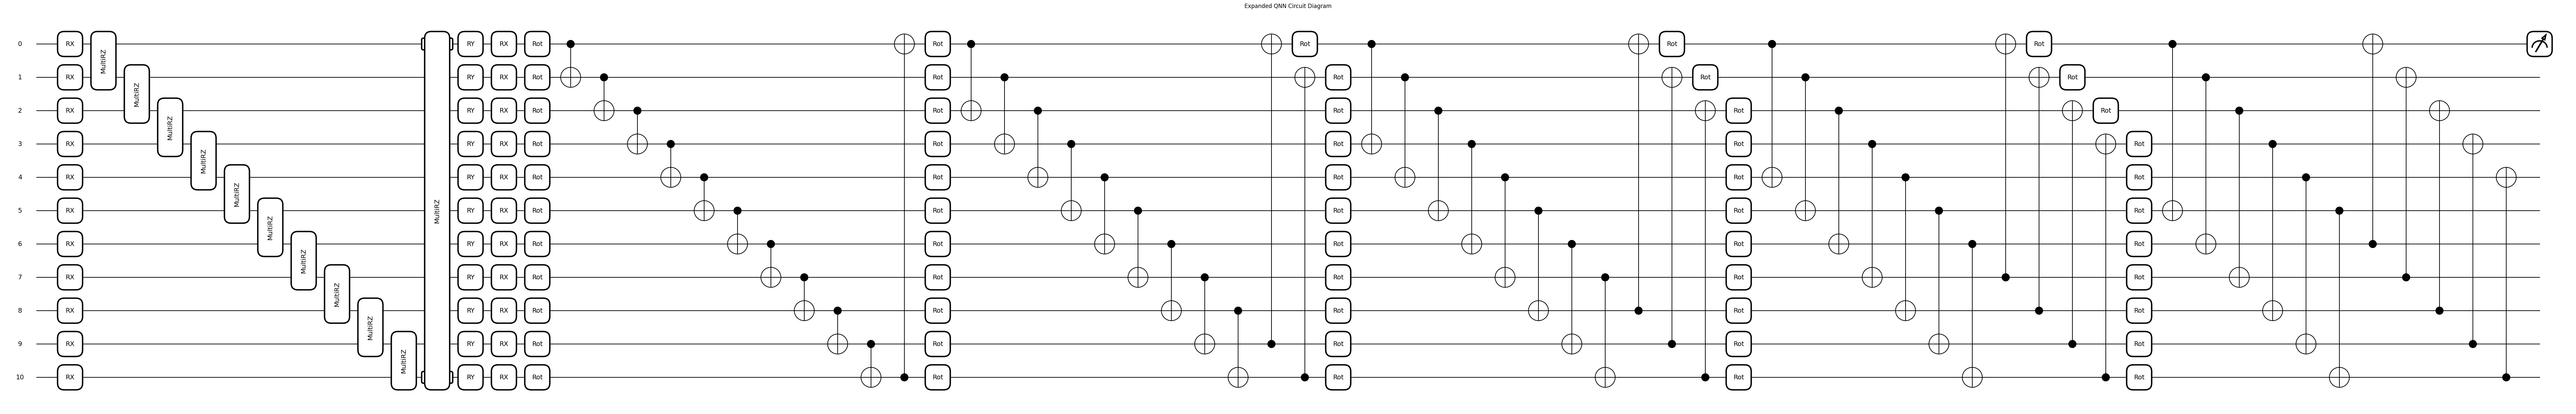

In [10]:
# Draw Full QNN diagram

# Set number of qubits to 11 (to match 11 input features)
n_qubits = 11  
embedding_depth = 1
entangling_depth = 5   
output_dim = 1  # Only one measurement for binary classification
dev = qml.device("default.qubit", wires=n_qubits)

@qml.qnode(dev, interface="torch")
def qnode(inputs, weights1, weights2):
    # QAOA embedding layer: embed the input data
    qml.templates.QAOAEmbedding(inputs, weights=weights1, wires=range(n_qubits))
    # Two strongly entangling layers for quantum processing
    qml.templates.StronglyEntanglingLayers(weights2, wires=range(n_qubits))
    # Return one expectation value from qubit 0 for classification 
    return [qml.expval(qml.PauliZ(0))]

ex_inputs   = np.random.random(n_qubits)
ex_weights1 = np.random.random((embedding_depth, 2 * n_qubits))
ex_weights2 = np.random.random((entangling_depth, n_qubits, 3))

# Basic Circuit Diagram (Text)
print("Basic Circuit Diagram (Text)")
default_diagram = qml.draw(qnode)(ex_inputs, ex_weights1, ex_weights2)
print(default_diagram)

fig_default = qml.draw_mpl(qnode)(ex_inputs, ex_weights1, ex_weights2)
plt.title("Default QNN Circuit Diagram")
plt.show()

# Expanded Circuit Diagram (Pennylane)
expanded_qnode = qml.transforms.decompose(qnode)

print("Expanded Circuit Diagram (Pennylane)")
expanded_diagram = qml.draw(expanded_qnode)(ex_inputs, ex_weights1, ex_weights2)
print(expanded_diagram)

fig_expanded = qml.draw_mpl(expanded_qnode)(ex_inputs, ex_weights1, ex_weights2)
plt.title("Expanded QNN Circuit Diagram")
plt.show()